In [6]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models

In [7]:
import os
os.chdir("/home/rgukt-basar/Downloads/iccad-official (1)/iccad-official/iccad1")

In [8]:
import os
os.listdir("train")

['nonhotspot', 'hotspot']

In [9]:
import os

os.makedirs("train/hotspot", exist_ok=True)
os.makedirs("train/nonhotspot", exist_ok=True)

os.makedirs("test/hotspot", exist_ok=True)
os.makedirs("test/nonhotspot", exist_ok=True)

In [10]:
import shutil
import os

for file in os.listdir("train"):
    
    if file.endswith(".png"):
        
        if file.startswith("HS"):
            shutil.move("train/" + file, "train/hotspot/" + file)
        
        elif file.startswith("NHS"):
            shutil.move("train/" + file, "train/nonhotspot/" + file)

In [11]:
for file in os.listdir("test"):
    
    if file.endswith(".png"):
        
        if file.startswith("HS"):
            shutil.move("test/" + file, "test/hotspot/" + file)
        
        elif file.startswith("NNHS"):
            shutil.move("test/" + file, "test/nonhotspot/" + file)

In [12]:
import os
os.listdir("train")

['nonhotspot', 'hotspot']

In [13]:
import os
print(os.listdir("test")[:10])

['nonhotspot', 'hotspot']


In [14]:
import os
os.listdir("test")

['nonhotspot', 'hotspot']

In [15]:
transform=transforms.Compose([transforms.Resize((128,128)),
                              transforms.Grayscale(),
                              transforms.ToTensor()
                             ])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")#cude means gpu
train_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
test_transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
train_dataset=datasets.ImageFolder("train",transform=train_transform)
test_dataset=datasets.ImageFolder("test",transform=test_transform)
train_loader=DataLoader(train_dataset,batch_size=16,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=16)



In [16]:
print(train_dataset.classes)
print(len(train_dataset))
print(len(test_dataset))

['hotspot', 'nonhotspot']
439
4905


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

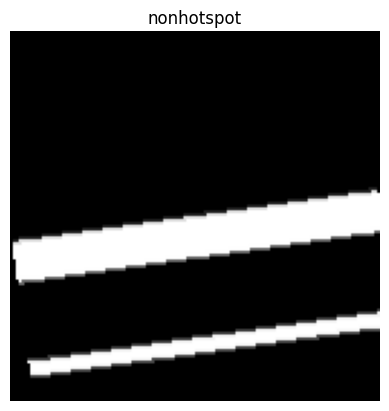

In [17]:
import matplotlib.pyplot as plt
images,labels=next(iter(train_loader))#labels means separets hotspot and non hotspot
#images are inputs,takes batches and iters for ever batch using next
plt.imshow(images[0][0],cmap="gray")#It is used to display an image on the screen.
plt.title(train_dataset.classes[labels[0]])
plt.axis("off")#only for image


In [18]:
# import torch
# import torch.nn as nn
# class CNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv=nn.Sequential(
#             nn.Conv2d(1,32,3),#greyscale image(inp=1,out=32,kernals)#rgb(inp=3)
#             nn.ReLU(),
#             nn.MaxPool2d(2),#2*2 pooling
#             nn.Conv2d(32,64,3),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(64,128,3),
#             nn.ReLU(),
#             nn.MaxPool2d(2)
#         )
#         #Linear used for classification
#         self.fc=nn.Sequential(
#             nn.Linear(128*14*14,256),
#             nn.ReLU(),
#             nn.Dropout(0.5),
#             nn.Linear(256,2)
#         )
#     def forward(self,x):
#         x=self.conv(x)
#         x = x.view(x.size(0),-1)#faltteing
#         x = self.fc(x)
#         return x
model = models.resnet18(weights="IMAGENET1K_V1")

# Change final layer for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

# -----------------------------
# Loss and Optimizer
# -----------------------------
weights = torch.tensor([4905/439 , 1]).to(device)#we got [11.7,1] means more importance to hotspots

criterion = nn.CrossEntropyLoss(weight=weights)
# criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
        
            
            
        

In [19]:
# model=CNN()
# criterion=nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# for epoch in range(50):
#     for images,labels in train_loader:
#         images=images.to(device)
#         labels=labels.to(device)
#         outputs=model(images)
#         loss=criterion(outputs,labels)
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#     print("Epoch:", epoch, "Loss:", loss.item())
for epoch in range(5):

    for i,(images,labels) in enumerate(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i %50 == 0:
            print("Epoch:",epoch+1,"Batch:",i,"Loss:",loss.item())
        

Epoch: 1 Batch: 0 Loss: 0.42955827713012695
Epoch: 2 Batch: 0 Loss: 0.3713362514972687
Epoch: 3 Batch: 0 Loss: 0.09674368053674698
Epoch: 4 Batch: 0 Loss: 0.17527839541435242
Epoch: 5 Batch: 0 Loss: 0.2892173230648041


In [20]:
import numpy as np
correct=0
total=0
all_preds=[]
all_labels=[]
with torch.no_grad():
    for images,labels in test_loader:
        images=images.to(device)
        labels=labels.to(device)
        outputs=model(images)
        _,predicted=torch.max(outputs,1)#returns maxvalue in tensor and index from outputs
        #but stores only index that why _,
        total+=labels.size(0)
        correct+=(predicted==labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    

print("Accuracy:",100*correct/total)
        

Accuracy: 71.29459734964323


In [25]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(all_labels,all_preds))
print(confusion_matrix(all_labels,all_preds))


              precision    recall  f1-score   support

           0       0.05      0.29      0.08       226
           1       0.96      0.73      0.83      4679

    accuracy                           0.71      4905
   macro avg       0.50      0.51      0.46      4905
weighted avg       0.91      0.71      0.80      4905

[[  65  161]
 [1247 3432]]


In [26]:
torch.save(model.state_dict(), "hotspot_model.pth")

In [27]:
ls

hotspot_model.pth  test/  train/


In [28]:
import os
print(os.getcwd())

/home/rgukt-basar/Downloads/iccad-official (1)/iccad-official/iccad1


In [29]:
import sys
print(sys.executable)

/home/rgukt-basar/anaconda3/bin/python3
